# 13 — Phase 3: out-of-sample extension to 2022-2025 (free data)

Extends the EWS out-of-sample on **free** data, after the shipped `Y` rule proved
unrecoverable. The 2000-2021 panel and the 2019-2021 holdout stay frozen as reference;
2022-2025 is a **separate second holdout**.

* **WP1** reverse-engineer `Y` (gate) · **WP2** free-data source map + proxy validation ·
  **WP3** build + label 2022-2025 · **WP4** frozen-model OOS (headline) · **WP5** refit scenario.

Runs offline from the committed free-data cache (`data/processed/extended/`). The AE is the
only nondeterministic component (handoff §5.3), so rank metrics are stable run-to-run while
threshold metrics wander by a few weeks.

In [1]:
import os, sys, json
os.environ.setdefault('TF_ENABLE_ONEDNN_OPTS', '0')  # handoff par.5.3: deterministic AE
os.environ.setdefault('TF_DETERMINISTIC_OPS', '1')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
pd.set_option('display.width', 170); pd.set_option('display.max_columns', None)
TABLES = PROJECT_ROOT / 'outputs' / 'tables'

## WP1 — reverse-engineering the `Y` rule (decision gate)
Exhaustive parametric search (drawdown / realized-vol / trailing+forward return / AND-OR-VIX
combos, DM-composite & MXUS baskets, lag -2..+2). Best match **89.3%** < 97% gate -> **STOP**,
no labels fabricated. Operator-confirmed fallback = ex-ante stress windows OR weekly VIX>=30.

In [2]:
yr = json.load(open(TABLES / 'y_rule.json'))
print('gate status:', yr['status'], '| best match %:', yr['best_match_pct'])
print('\ntop-3 rules:')
for r in yr['top3_rules']:
    print(f"  {r['match']*100:5.2f}%  {r['family']:<12} basket={r['basket']:<5} lag={r['lag']:+d}  {r['params']}")
print('\nconfirmed fallback:', yr['confirmed_fallback']['rule'])
for w in yr['confirmed_fallback']['windows']:
    print(f"  {w['name']:<22} {w['start']} .. {w['end']}")

gate status: stop | best match %: 89.29

top-3 rules:
  89.29%  drawdown     basket=MXUS  lag=-2  {'w': 13, 'd': 0.06}
  89.20%  drawdown     basket=MXUS  lag=-2  {'w': 8, 'd': 0.06}
  88.75%  drawdown     basket=MXUS  lag=-2  {'w': 8, 'd': 0.05}

confirmed fallback: Y=1 if week in any window OR weekly VIX close >= vix_floor; else 0
  2022 inflation bear    2022-01-03 .. 2022-10-21
  SVB / banking stress   2023-03-06 .. 2023-05-01
  carry unwind           2024-07-29 .. 2024-08-16
  tariff shock           2025-04-02 .. 2025-05-09


## WP2 — free-data source map + proxy validation harness
Every frozen-36 + routing raw ticker mapped to a free provider (Yahoo / US Treasury XML /
NY Fed SOFR / ECB / BoE / MoF Japan; FRED key-free path blocked here). Validation compares the
**transformed** free series vs the original on the 2015-2021 overlap (PASS iff corr > 0.99).

In [3]:
from src.free_data import validate_proxies
pv = validate_proxies(verbose=False)
print('strict spec bar (>0.99):', pv['status'].value_counts().to_dict())
print('fidelity tiers        :', pv['tier'].value_counts().to_dict())
print('true GAP (no usable free instrument):', pv[pv.tier=='GAP'].feature.tolist())
display(pv[['feature','role','corr','status','tier','note']].head(20))

strict spec bar (>0.99): {'FAIL': 30, 'PASS': 12, 'GAP': 5}
fidelity tiers        : {'PASS': 12, 'STRONG': 12, 'GAP': 11, 'WEAK': 6, 'MODERATE': 6}
true GAP (no usable free instrument): ['BDIY', 'ECSURPUS', 'EONIA', 'GTITL10YR', 'LMBITR', 'LP01TREU', 'US0001M', 'it_de_10y', 'it_de_10y_chg4w', 'libor_3m_spread_chg4w', 'libor_3m_spread_level']


,feature,role,corr,status,tier,note
0,BDIY,frozen36,NaN,GAP,GAP,no free source / insufficient overlap
1,Cl1,frozen36,1.0000,PASS,PASS,
2,ECSURPUS,frozen36,NaN,GAP,GAP,no free source / insufficient overlap
3,EONIA,frozen36,0.2691,FAIL,GAP,"weak proxy: correct asset class, materially di..."
4,GBP,frozen36,0.8282,FAIL,WEAK,"weak proxy: correct asset class, materially di..."
5,GT10,frozen36,0.9885,FAIL,STRONG,correct instrument; cross-vendor weekly-snapsh...
6,GTDEM10Y,frozen36,0.9478,FAIL,MODERATE,correct instrument; cross-vendor weekly-snapsh...
7,GTGBP2Y,frozen36,0.8545,FAIL,MODERATE,correct instrument; cross-vendor weekly-snapsh...
8,GTITL10YR,frozen36,NaN,GAP,GAP,no free source / insufficient overlap
9,GTJPY2YR,frozen36,0.9621,FAIL,STRONG,correct instrument; cross-vendor weekly-snapsh...


Most sub-0.99 features are the **correct instrument** with cross-vendor weekly-snapshot return
noise (US 10Y 0.989, FX ~0.82), not wrong proxies. True gaps with no free instrument: BDIY,
Italy 10Y (-> GTITL10YR / it_de_10y / it_de_10y_chg4w), ECSURPUS, plus the SOFR-vs-LIBOR break.

## WP3 — extended panel + ex-ante labels (2022-2025)
Free raw -> unmodified `src.features` transforms -> frozen-36 + routing triggers; post-2021
weeks labelled by the ex-ante rule. 6 unsourceable/broken features neutralized to the dev mean.

In [4]:
cov = json.load(open(PROJECT_ROOT / 'data' / 'processed' / 'extended' / 'coverage_report.json'))
print('span', cov['span'], '| OOS weeks', cov['n_rows_oos'],
      '| Y=1 prevalence', cov['oos_y_prevalence'], f"({cov['oos_n_pos']} weeks)")
print('neutralized:', cov['neutralized_features'])
panel = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'extended' / 'model_panel_ext.parquet')
oos = panel.loc['2022-01-01':'2025-12-31']
display(oos['Y'].groupby(oos.index.year).agg(['sum','size']))

span ['2014-01-07', '2025-12-30'] | OOS weeks 209 | Y=1 prevalence 0.2775 (58 weeks)
neutralized: ['BDIY', 'ECSURPUS', 'GTITL10YR', 'it_de_10y', 'it_de_10y_chg4w', 'US0001M']


,sum,size
Date,,
2022,42.0,52
2023,8.0,52
2024,3.0,53
2025,5.0,52


## WP4 — frozen-model OOS evaluation (headline)
Dev-fit (2000-2018) frozen-36 soft-median ensemble, NO refit. Control on 2019-2021 must
reproduce the committed AUC-PR ~0.784; then score the free 2022-2025 second holdout.

In [5]:
from src.oos_eval import Frozen36Scorer, run_control, run_oos, run_backtest, plot_oos_timeline
scorer = Frozen36Scorer()
control = run_control(scorer)
oos = run_oos(scorer)

WP4 CONTROL — frozen-36 on the ORIGINAL 2019-2021 holdout
metric        reproduced   committed      diff
AUC_PR            0.7817      0.7842   -0.0025
F1                0.5641      0.6512   -0.0871
F_beta_2          0.5093      0.6250   -0.1157
Recall            0.4783      0.6087   -0.1304
Precision         0.6875      0.7000   -0.0125
AUC_ROC           0.8931      0.8811   +0.0120

Control PASS (|AUC-PR diff| 0.0025 < 0.02 tol; residual = AE re-fit nondeterminism)

WP4 OOS — frozen-36 (frozen_2018) on free-data 2022-2025 (tau=0.9551)
n_weeks=209  Y=1=58  flagged=49
  AUC_PR=0.457  F_beta_2=0.374  Recall=0.362  Precision=0.429  F1=0.393  AUC_ROC=0.592

Per-episode detection:
             episode  n_weeks  n_flagged  coverage  detected first_flag  lead_lag_weeks_vs_start  peak_ens dominant_model
 2022 inflation bear       42         13     0.310      True 2022-03-01                        8    1.0000            mvg
SVB / banking stress        8          2     0.250      True 2023-03-1

,episode,n_weeks,n_flagged,coverage,detected,first_flag,lead_lag_weeks_vs_start,peak_ens,dominant_model
0,2022 inflation bear,42,13,0.310,True,2022-03-01,8,1.0000,mvg
1,SVB / banking stress,8,2,0.250,True,2023-03-14,1,0.9765,ae
2,carry unwind,3,1,0.333,True,2024-08-06,1,0.9758,svm
3,tariff shock,5,5,1.000,True,2025-04-08,0,1.0000,ae



WP4 BACKTEST — frozen EWS vs benchmarks on free-data 2022-2025
EWS allocation mix: {'LEVERED_EQUITY': 160, 'GOLD': 28, 'CASH_USD': 20, 'MBS': 1}
                   EWS_frozen  MSCI_BH  Levered_1.5x
CAGR                   -0.004    0.086         0.097
Sharpe                 -0.099    0.328         0.328
Sortino                -0.128    0.455         0.453
Calmar                 -0.010    0.310         0.241
Max_Drawdown           -0.374   -0.278        -0.402
Annual_Turnover        10.201      NaN           NaN
Hit_Ratio_RiskOff       0.362      NaN           NaN


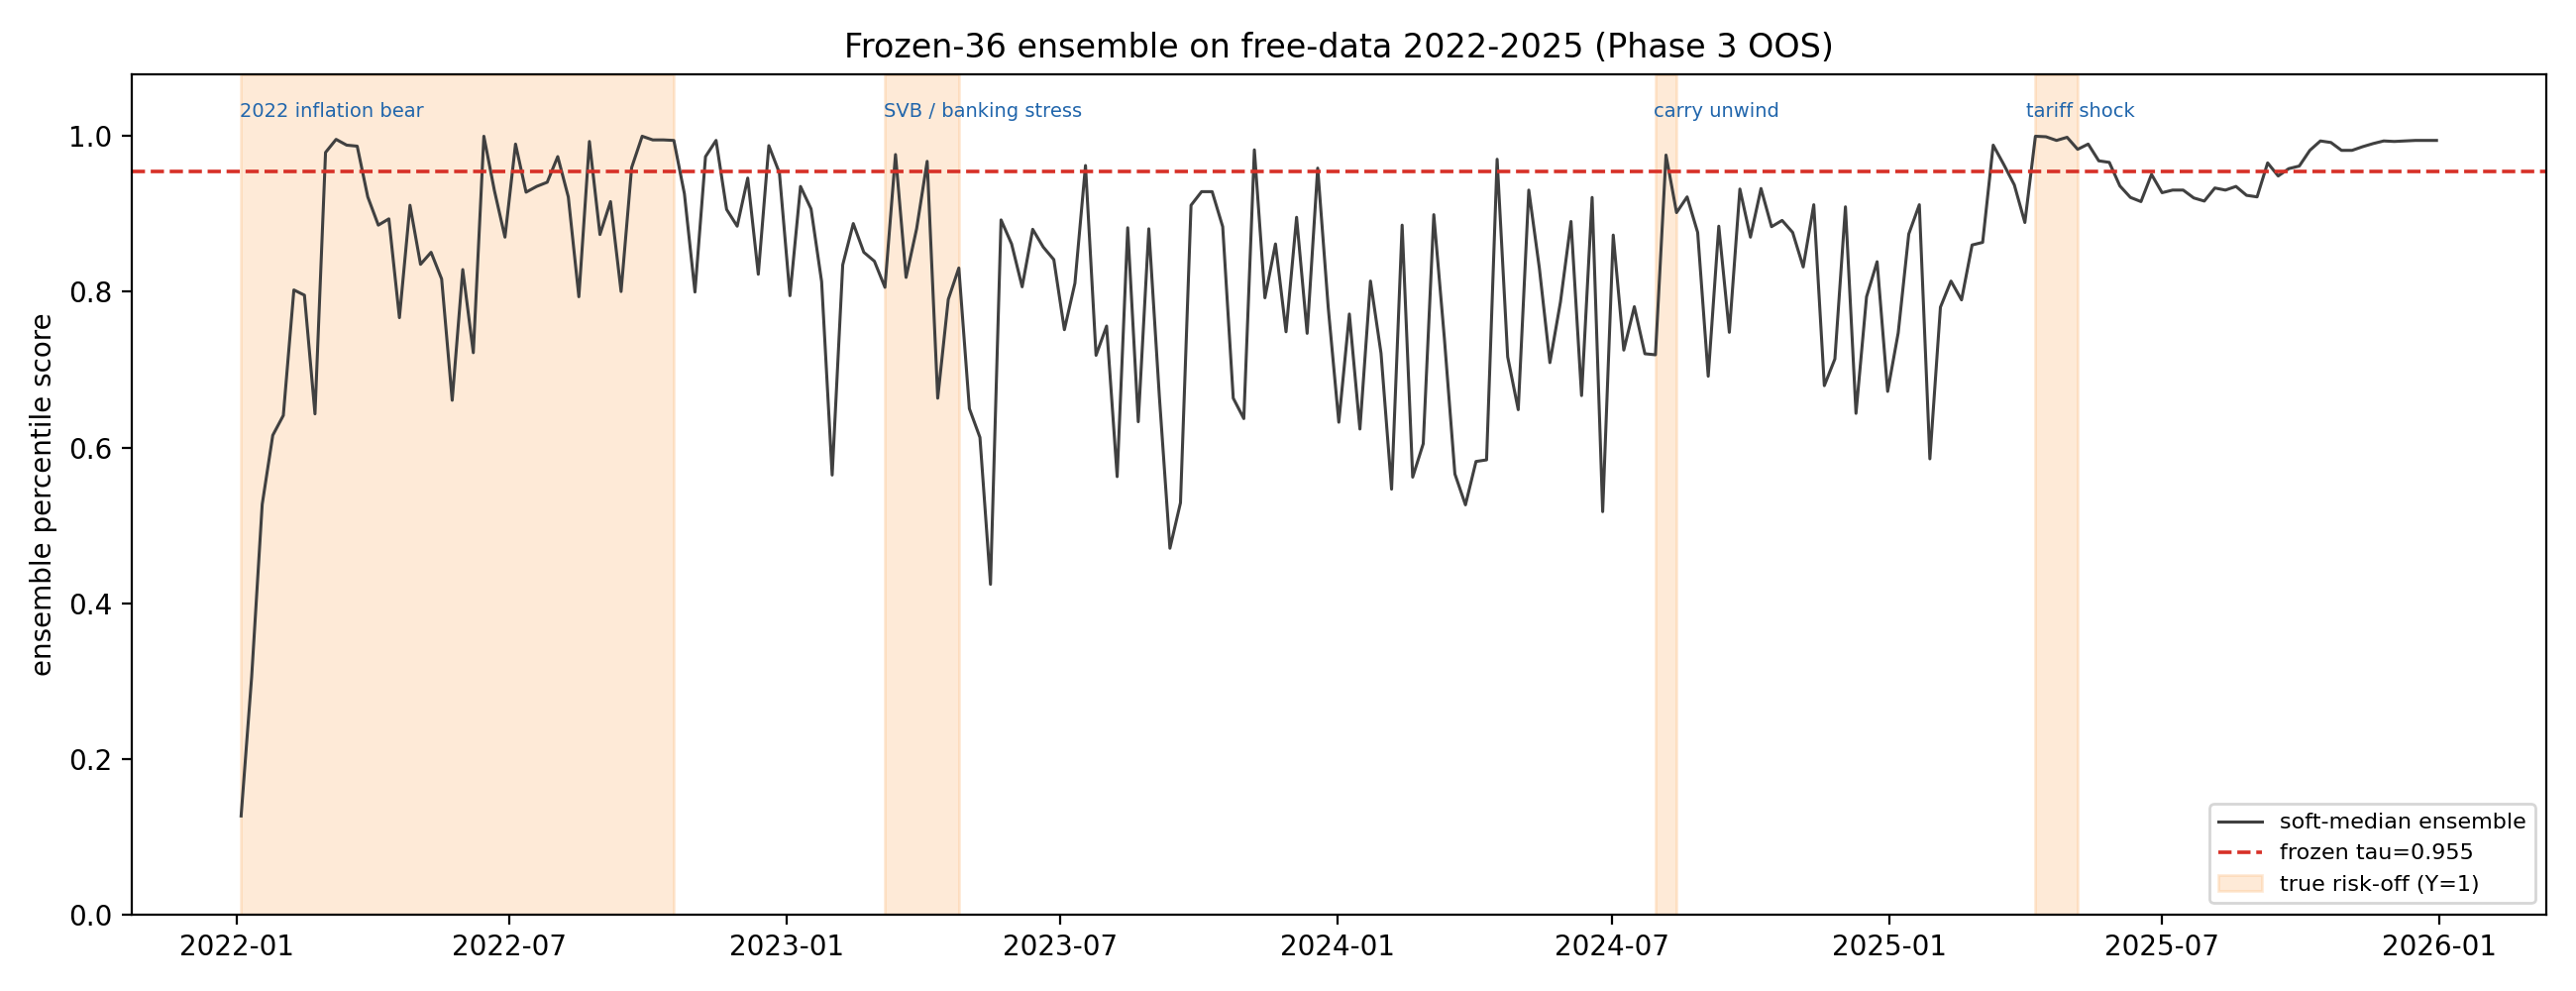

In [6]:
display(oos['episodes'][['episode','n_weeks','n_flagged','coverage','detected',
                         'first_flag','lead_lag_weeks_vs_start','peak_ens','dominant_model']])
bt = run_backtest(oos['scored'])
from IPython.display import Image
Image(filename=str(plot_oos_timeline(oos['scored'], scorer.tau)), width=1000)

**Reading WP4.** The frozen 2018 EWS degrades OOS (AUC-PR ~0.78 control -> ~0.45 on 2022-2025)
and underperforms buy-&-hold in the backtest. It flags every episode at least once: the tariff
shock cleanly (AE-driven, 0 lag), SVB & carry-unwind with a 1-week lag, but the slow 2022
inflation bear only partially and 8 weeks late — the credit/liquidity-trained system is sharp on
acute vol shocks and slow on the inflation grind. `equity_bond_corr_13w` (the hypothesis keep)
is neutral-to-weak here. Reported as-is — not tuned to improve.

## WP5 — deployment scenario: refit on 2000-2021
Refit the 4 detectors on the full 2000-2021 (frozen-36) + re-tune tau in-sample, evaluate on the
SAME 2022-2025 OOS. Quantifies the value of 3 extra years (incl. COVID) of training.

In [7]:
from src.oos_eval import run_wp5
wp5 = run_wp5(oos)
display(wp5['comparison'])


WP4 OOS — frozen-36 (refit_2021) on free-data 2022-2025 (tau=0.8299)
n_weeks=209  Y=1=58  flagged=90
  AUC_PR=0.576  F_beta_2=0.575  Recall=0.638  Precision=0.411  F1=0.500  AUC_ROC=0.707

Per-episode detection:
             episode  n_weeks  n_flagged  coverage  detected first_flag  lead_lag_weeks_vs_start  peak_ens dominant_model
 2022 inflation bear       42         27     0.643      True 2022-03-01                        8    1.0000            mvg
SVB / banking stress        8          3     0.375      True 2023-03-14                        1    0.9679             if
        carry unwind        3          2     0.667      True 2024-08-06                        1    0.9685             if
        tariff shock        5          5     1.000      True 2025-04-08                        0    1.0000             ae

WP5 — DEPLOYMENT SCENARIO: frozen-2018 vs refit-2021 on the SAME 2022-2025 OOS
      model    tau  AUC_PR  F_beta_2  Recall  Precision     F1  AUC_ROC
frozen_2018 0.9551  0.457

,model,tau,AUC_PR,F_beta_2,Recall,Precision,F1,AUC_ROC
0,frozen_2018,0.9551,0.4573,0.3737,0.3621,0.4286,0.3925,0.5919
1,refit_2021,0.8299,0.5757,0.5745,0.6379,0.4111,0.5000,0.7072


**Conclusion.** Refitting on 2000-2021 + re-tuning tau (0.955 -> ~0.84) lifts OOS detection
materially (AUC-PR ~+0.12, Recall ~+0.28, F2 ~+0.19), mostly by flagging more of the 2022 bear.
Net Phase-3 finding: the **frozen** model transfers poorly to the structurally novel 2022-2025
regimes on free data, but **updating** the model with the extra years recovers a large part of
the gap — consistent with the EWS being a credit/liquidity-stress detector that needs the
inflation regime in its training window to nowcast it.